In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

df = pd.read_csv("Dataset.csv")
df = df.drop_duplicates(subset="title").reset_index(drop=True)
print(df.shape)
df.head()

(8787, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
def clean_genre(g):
    g = re.sub(r"\b(TV|Shows?|Movies?)\b", "", g).strip(" '")
    return re.sub(r"\s+", " ", g).strip().lower()

genres = df["listed_in"].apply(
    lambda s: [t for t in (clean_genre(x) for x in s.split(",")) if t])
mlb = MultiLabelBinarizer()
G = pd.DataFrame(mlb.fit_transform(genres), columns=mlb.classes_)
print(G.shape[1], "genre columns")

maturity_map = {"TV-Y": 0, "TV-Y7": 0, "TV-Y7-FV": 0, "TV-G": 0, "G": 0,
                "TV-PG": 1, "PG": 1, "TV-14": 2, "PG-13": 2,
                "TV-MA": 3, "R": 3, "NC-17": 3}
duration_num = df["duration"].str.extract(r"(\d+)")[0].astype(float)

X_num = pd.DataFrame({
    "is_tv":        (df["type"] == "TV Show").astype(int),
    "release_year": df["release_year"],
    "minutes":      np.where(df["type"] == "Movie", duration_num, 0).clip(0, 200),  # clip extreme outliers
    "seasons":      np.where(df["type"] == "TV Show", duration_num, 0).clip(0, 5),
    "has_director": (df["director"] != "Not Given").astype(int),
    "maturity":     df["rating"].map(maturity_map),
})
X_num["maturity"] = X_num["maturity"].fillna(X_num["maturity"].median())
X_num.describe().round(2)

32 genre columns


,is_tv,release_year,minutes,seasons,has_director,maturity
count,8787.00,8787.00,8787.00,8787.00,8787.00,8787.00
mean,0.30,2014.18,69.34,0.50,0.71,2.12
std,0.46,8.83,51.32,0.99,0.46,0.99
min,0.00,1925.00,0.00,0.00,0.00,0.00
25%,0.00,2013.00,0.00,0.00,0.00,2.00
50%,0.00,2017.00,88.00,0.00,1.00,2.00
75%,1.00,2019.00,106.00,1.00,1.00,3.00
max,1.00,2021.00,200.00,5.00,1.00,3.00


In [ ]:
X_num_scaled = pd.DataFrame(StandardScaler().fit_transform(X_num), columns=X_num.columns)

GENRE_WEIGHT = 2.0
X = pd.concat([X_num_scaled, G * GENRE_WEIGHT], axis=1).astype(float)
print("Final feature matrix:", X.shape)

Final feature matrix: (8787, 38)


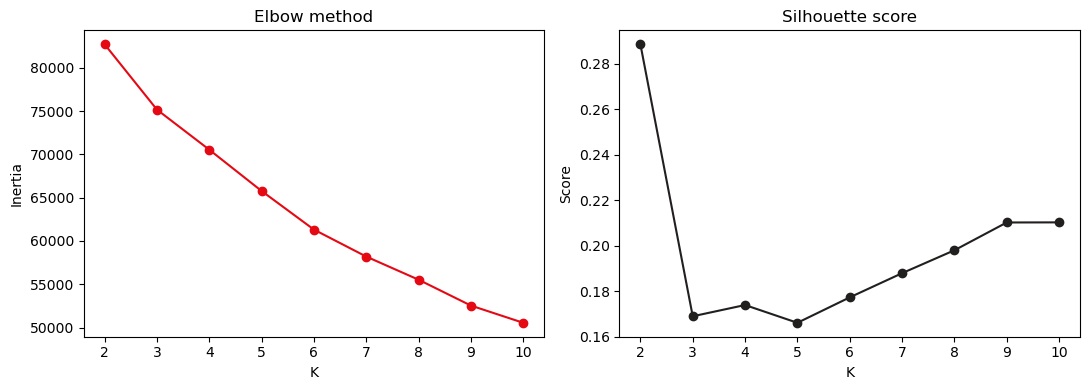

,Inertia,Silhouette
K,,
2,82712.0,0.289
3,75167.0,0.169
4,70537.0,0.174
5,65768.0,0.166
6,61311.0,0.177
7,58194.0,0.188
8,55521.0,0.198
9,52535.0,0.210
10,50547.0,0.210


In [12]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=4000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertias, marker="o", color="#e50914"); ax[0].set_title("Elbow method")
ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sils, marker="o", color="#221f1f"); ax[1].set_title("Silhouette score")
ax[1].set_xlabel("K"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()
pd.DataFrame({"K": list(ks), "Inertia": np.round(inertias), "Silhouette": np.round(sils, 3)}).set_index("K")

In [13]:
K = 7
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
df["cluster"] = kmeans.labels_
print("Silhouette score (K-Means, K=7):",
      round(silhouette_score(X, kmeans.labels_, sample_size=4000, random_state=42), 3))
df["cluster"].value_counts().sort_index()

Silhouette score (K-Means, K=7): 0.188


0     405
1    1356
2    1982
3     664
4     675
5    2178
6    1527
Name: cluster, dtype: int64

In [14]:
idx = np.random.default_rng(42).choice(len(X), 3000, replace=False)
agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X.iloc[idx])
comparison = pd.DataFrame({
    "Silhouette": [silhouette_score(X.iloc[idx], kmeans.labels_[idx]),
                   silhouette_score(X.iloc[idx], agg.labels_)]},
    index=["K-Means", "Agglomerative (ward)"]).round(3)
print("Agreement between the two methods (ARI):",
      round(adjusted_rand_score(kmeans.labels_[idx], agg.labels_), 3))
comparison

Agreement between the two methods (ARI): 0.649


,Silhouette
K-Means,0.183
Agglomerative (ward),0.168


In [15]:
def top_genres(idx, n=3):
    return ", ".join(G.loc[idx].mean().sort_values(ascending=False).head(n).index)

def safe_round(x):
    return round(x) if pd.notna(x) else np.nan

rows = []
for c in sorted(df["cluster"].unique()):
    g = df[df["cluster"] == c]
    movie_minutes = X_num.loc[g.index, "minutes"].where(g["type"] == "Movie").replace(0, np.nan)
    rows.append({
        "Cluster":           c,
        "Titles":            len(g),
        "% TV Shows":        round(100 * (g["type"] == "TV Show").mean()),
        "Avg release year":  round(g["release_year"].mean()),
        "Avg movie minutes": safe_round(movie_minutes.mean()),
        "% Kids-rated":      round(100 * (X_num.loc[g.index, "maturity"] == 0).mean()),
        "% Adult-rated":     round(100 * (X_num.loc[g.index, "maturity"] == 3).mean()),
        "% with director":   round(100 * (g["director"] != "Not Given").mean()),
        "Top genres":        top_genres(g.index),
    })
profile = pd.DataFrame(rows).set_index("Cluster")
profile

,Titles,% TV Shows,Avg release year,Avg movie minutes,% Kids-rated,% Adult-rated,% with director,Top genres
Cluster,,,,,,,,
0,405,1,1983,114.0,3,33,98,"dramas, action & adventure, international"
1,1356,0,2016,85.0,0,64,95,"documentaries, stand-up comedy, action & adven..."
2,1982,100,2017,NaN,0,58,10,"international, dramas, crime"
3,664,0,2015,76.0,58,0,93,"children & family, comedies, dramas"
4,675,100,2016,NaN,69,0,8,"kids, comedies, docuseries"
5,2178,0,2015,112.0,1,53,99,"dramas, international, independent"
6,1527,0,2015,101.0,2,47,98,"international, comedies, action & adventure"


In [ ]:
def name_cluster(row):
    kind = "TV" if row["% TV Shows"] >= 50 else "Movies"
    if row["% Kids-rated"] >= 40:
        audience = "for kids"
    elif row["% Adult-rated"] >= 55:
        audience = "mature"
    else:
        audience = "general"
    first_genres = ", ".join(row["Top genres"].split(", ")[:2])
    return f"{kind} ({audience}): {first_genres}"

profile["Name"] = profile.apply(name_cluster, axis=1)
names = profile["Name"].to_dict()
df["cluster_name"] = df["cluster"].map(names)
profile[["Name", "Titles"]]

,Name,Titles
Cluster,,
0,"Movies (general): dramas, action & adventure",405
1,"Movies (mature): documentaries, stand-up comedy",1356
2,"TV (mature): international, dramas",1982
3,"Movies (for kids): children & family, comedies",664
4,"TV (for kids): kids, comedies",675
5,"Movies (general): dramas, international",2178
6,"Movies (general): international, comedies",1527


Variance explained by the 2 components: [0.284 0.119]


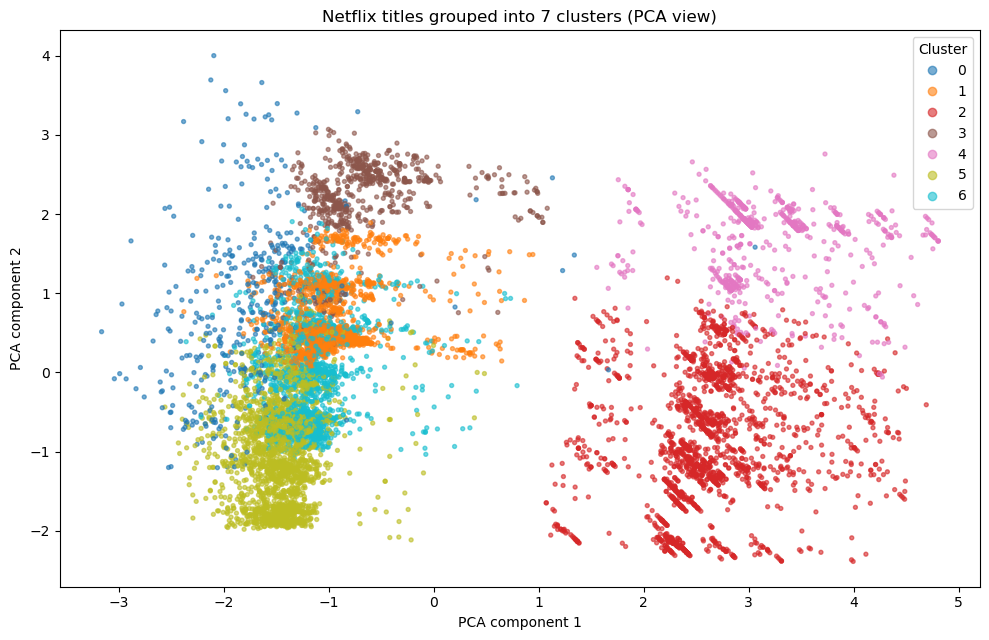

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
print("Variance explained by the 2 components:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(10, 6.5))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", s=8, alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best")
plt.xlabel("PCA component 1"); plt.ylabel("PCA component 2")
plt.title("Netflix titles grouped into 7 clusters (PCA view)")
plt.tight_layout(); plt.show()

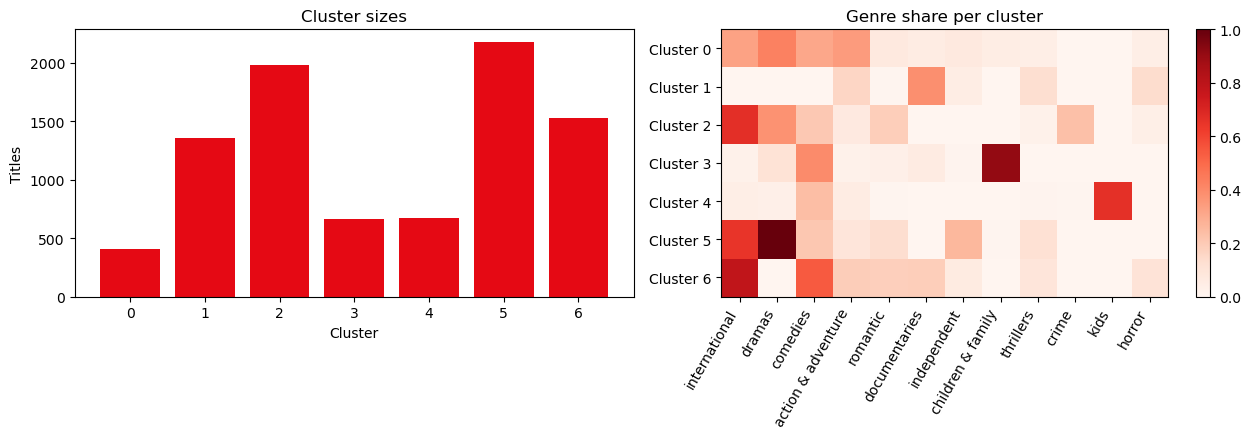

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sizes = df["cluster"].value_counts().sort_index()
ax[0].bar(sizes.index.astype(str), sizes.values, color="#e50914")
ax[0].set_title("Cluster sizes"); ax[0].set_xlabel("Cluster"); ax[0].set_ylabel("Titles")

common = G.sum().sort_values(ascending=False).head(12).index
share = G[common].groupby(df["cluster"]).mean()
im = ax[1].imshow(share.values, cmap="Reds", aspect="auto")
ax[1].set_xticks(range(len(common))); ax[1].set_xticklabels(common, rotation=60, ha="right")
ax[1].set_yticks(range(K)); ax[1].set_yticklabels([f"Cluster {c}" for c in share.index])
ax[1].set_title("Genre share per cluster"); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

In [ ]:
for c in sorted(df["cluster"].unique()):
    sample = df[df["cluster"] == c].sample(5, random_state=42)["title"].tolist()
    print(f"Cluster {c} - {names[c]}")
    print("   e.g.", "; ".join(sample), "\n")

Cluster 0 - Movies (general): dramas, action & adventure
   e.g. Rain Man; Fiddler on the Roof; Tunisian Victory; The Net; Midnight Run 

Cluster 1 - Movies (mature): documentaries, stand-up comedy
   e.g. Boyka: Undisputed; Cabin Fever; Surviving R. Kelly: The Impact; Dancing with the Birds; Deviant Love 

Cluster 2 - TV (mature): international, dramas
   e.g. Jeffrey Epstein: Filthy Rich; The West Wing; Señora Acero; Nailed It! Spain; El Dragón: Return of a Warrior 

Cluster 3 - Movies (for kids): children & family, comedies
   e.g. Luccas Neto in: Summer Camp; Jinxed; Garuda in My Heart 2; What a Girl Wants; Bruno and Boots: Go Jump in the Pool 

Cluster 4 - TV (for kids): kids, comedies
   e.g. DC Super Hero Girls; Word Party Songs; Yoko; Battlefield Recovery; Llama Llama 

Cluster 5 - Movies (general): dramas, international
   e.g. Caught by a Wave; Dolly Kitty Aur Woh Chamakte Sitare; You Get Me; Newness; Edge of Seventeen 

Cluster 6 - Movies (general): international, comedies
 